<a href="https://colab.research.google.com/github/pande17827/FastApi/blob/main/6.Serving%20ML%20Models%20with%20FastAPI/3.creting%20backend(post%20method).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("hello")

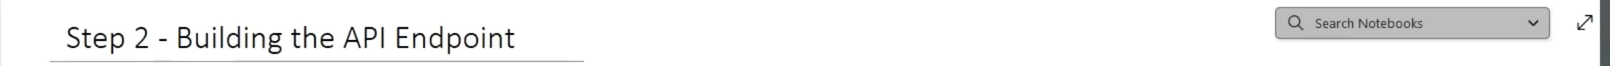

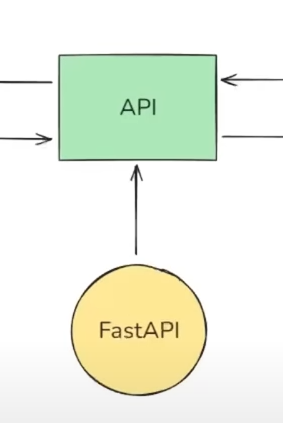

# <b> We will ask the user to provide the original like this

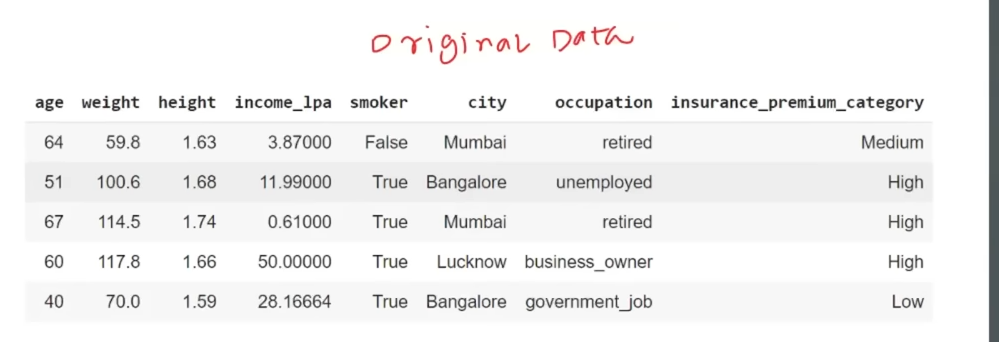

# <b> Because we dont user to do the feature enginnerring by himself

In [1]:

!pip install fastapi uvicorn pydantic nest-asyncio pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.5 MB/s eta 0:00:00


In [ ]:
from fastapi import FastAPI
from fastapi.responses import JSONResponse
from pydantic import BaseModel, Field, computed_field
from typing import Literal, Annotated
import pickle
import pandas as pd
from google.colab import userdata
from pyngrok import ngrok
import nest_asyncio
import uvicorn



# setting ngrok
ngrok_auth_token = userdata.get('NGROK_AUTHTOKEN')
ngrok.set_auth_token(ngrok_auth_token)

# import the ml model
with open('/content/model.pkl', 'rb') as f:
    model = pickle.load(f)

app = FastAPI()

tier_1_cities = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata", "Hyderabad", "Pune"]
tier_2_cities = [
    "Jaipur", "Chandigarh", "Indore", "Lucknow", "Patna", "Ranchi", "Visakhapatnam", "Coimbatore",
    "Bhopal", "Nagpur", "Vadodara", "Surat", "Rajkot", "Jodhpur", "Raipur", "Amritsar", "Varanasi",
    "Agra", "Dehradun", "Mysore", "Jabalpur", "Guwahati", "Thiruvananthapuram", "Ludhiana", "Nashik",
    "Allahabad", "Udaipur", "Aurangabad", "Hubli", "Belgaum", "Salem", "Vijayawada", "Tiruchirappalli",
    "Bhavnagar", "Gwalior", "Dhanbad", "Bareilly", "Aligarh", "Gaya", "Kozhikode", "Warangal",
    "Kolhapur", "Bilaspur", "Jalandhar", "Noida", "Guntur", "Asansol", "Siliguri"
]

# pydantic model to validate incoming data
class UserInput(BaseModel):

    age: Annotated[int, Field(..., gt=0, lt=120, description='Age of the user')]
    weight: Annotated[float, Field(..., gt=0, description='Weight of the user')]
    height: Annotated[float, Field(..., gt=0, lt=2.5, description='Height of the user')]
    income_lpa: Annotated[float, Field(..., gt=0, description='Annual salary of the user in lpa')]
    smoker: Annotated[bool, Field(..., description='Is user a smoker')]
    city: Annotated[str, Field(..., description='The city that the user belongs to')]
    occupation: Annotated[Literal['retired', 'freelancer', 'student', 'government_job',
       'business_owner', 'unemployed', 'private_job'], Field(..., description='Occupation of the user')]

    @computed_field
    @property
    def bmi(self) -> float:
        return self.weight/(self.height**2)

    @computed_field
    @property
    def lifestyle_risk(self) -> str:
        if self.smoker and self.bmi > 30:
            return "high"
        elif self.smoker or self.bmi > 27:
            return "medium"
        else:
            return "low"

    @computed_field
    @property
    def age_group(self) -> str:
        if self.age < 25:
            return "young"
        elif self.age < 45:
            return "adult"
        elif self.age < 60:
            return "middle_aged"
        return "senior"

    @computed_field
    @property
    def city_tier(self) -> int:
        if self.city in tier_1_cities:
            return 1
        elif self.city in tier_2_cities:
            return 2
        else:
            return 3

@app.post('/predict')
def predict_premium(data: UserInput):

    input_df = pd.DataFrame([{
        'bmi': data.bmi,
        'age_group': data.age_group,
        'lifestyle_risk': data.lifestyle_risk,
        'city_tier': data.city_tier,
        'income_lpa': data.income_lpa,
        'occupation': data.occupation
    }])

    prediction = model.predict(input_df)[0]

    return JSONResponse(status_code=200, content={'predicted_category': prediction})


# Apply nest_asyncio to allow running uvicorn inside notebook
nest_asyncio.apply()

# Open an ngrok tunnel to the default uvicorn port 8000
public_url = ngrok.connect(8000)
print(f"Public URL: {public_url}")

# Run the FastAPI app
uvicorn.run(app, host="0.0.0.0", port=8000)





INFO:     Started server process [234]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Public URL: NgrokTunnel: "https://64eb-35-196-214-64.ngrok-free.app" -> "http://localhost:8000"
INFO:     2402:a00:405:d365:2142:6eb5:f176:2080:0 - "GET / HTTP/1.1" 404 Not Found
INFO:     2402:a00:405:d365:2142:6eb5:f176:2080:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     2402:a00:405:d365:2142:6eb5:f176:2080:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     2402:a00:405:d365:2142:6eb5:f176:2080:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     2402:a00:405:d365:2142:6eb5:f176:2080:0 - "POST /predict HTTP/1.1" 200 OK
